In [12]:
import numpy as np
import os
import pandas as pd
from pathlib import Path
from collections import Counter
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')

### Load Joblib Models

In [8]:
import joblib

# To get the joblib files, run the respective notebooks for each model.
knn = joblib.load('../models/KNN_3_sec.joblib')
mlp = joblib.load('../models/MLP_3_sec.joblib')
svm = joblib.load('../models/SVM_3_sec.joblib')

In [9]:
# Segment durations to test
SEGMENT_DURATIONS = [3, 6, 10]
# Columns not taken into consideration for training the model, as they are not relevant for genre classification or are redundant.
COLUMNS_TO_DROP = ['filename', 'label', 'length', 'tempo','harmony_mean', 'harmony_var', 'perceptr_var', 'perceptr_mean']

### Test Single Song

In [10]:
import warnings
warnings.filterwarnings('ignore')

from src.extract_features import extract_features

genre = "hiphop"
number = "00099"

file_path = f'../data/genres_original/{genre}/{genre}.{number}.wav'
song_features = extract_features(file_path, label=genre, segment_duration=10)
song_features

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,hiphop.00099.wav,10.0,0.429756,0.093071,0.151412,0.012248,1823.076302,539770.334863,1867.156099,149783.620729,...,72.588882,-7.491683,57.875557,-0.410967,56.910744,-3.823745,85.849022,-4.057207,41.536137,hiphop
1,hiphop.00099.wav,10.0,0.423440,0.097810,0.162481,0.016202,1950.628836,698470.507982,1918.591941,112889.930767,...,53.614853,-7.336004,45.515388,-1.477373,92.554817,-8.391605,57.425705,-5.738699,62.990093,hiphop
2,hiphop.00099.wav,10.0,0.439708,0.093978,0.146866,0.016171,2120.148732,745594.189497,1968.885734,123307.817310,...,62.246616,-8.406807,53.174770,-1.695142,69.312218,-7.406522,64.771393,-6.310313,74.835922,hiphop


In [13]:
X_song = song_features.drop(columns=COLUMNS_TO_DROP)
X_song_scaled = knn["scaler"].transform(X_song)
y_pred_knn = knn["model"].predict(X_song_scaled)

genre_labels = [knn["label_encoder"].classes_[int(label)] for label in y_pred_knn]
print(genre_labels)

counter = Counter(genre_labels)

print("Predicted Genre:", counter.most_common(1)[0][0])
print("Confidence:", round(counter.most_common(1)[0][1] / len(genre_labels), 3))

# Check if prediction is correct
actual_genre = song_features['label'].iloc[0]
predicted_genre = counter.most_common(1)[0][0]
is_correct_knn = predicted_genre == actual_genre
print(f"Is Correct (KNN): {is_correct_knn}")

['hiphop', 'hiphop', 'hiphop']
Predicted Genre: hiphop
Confidence: 1.0
Is Correct (KNN): True


In [15]:
X_song = song_features.drop(columns=COLUMNS_TO_DROP)
input_data = X_song.values
scaled_input = mlp["scaler"].transform(input_data)
predictions_proba = mlp["model"].predict(scaled_input)

predicted_classes = np.argmax(predictions_proba, axis=1)
genre_labels_mlp = [mlp["label_encoder"].classes_[int(label)] for label in predicted_classes]
print(genre_labels_mlp)

counter_mlp = Counter(genre_labels_mlp)

print("Predicted Genre:", counter_mlp.most_common(1)[0][0].upper())
print("Confidence:", round(counter_mlp.most_common(1)[0][1] / len(genre_labels_mlp) * 100, 3))

# Check if prediction is correct
predicted_genre_mlp = counter_mlp.most_common(1)[0][0]
is_correct_mlp = predicted_genre_mlp == actual_genre
print(f"Is Correct (MLP): {is_correct_mlp}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
['hiphop', 'hiphop', 'hiphop']
Predicted Genre: HIPHOP
Confidence: 100.0
Is Correct (MLP): True


In [16]:
seg_preds = svm["model"].predict(X_song)
print(seg_preds)

counter_svm = Counter(seg_preds)

print("Predicted Genre:", counter_svm.most_common(1)[0][0])
print("Confidence:", round(counter_svm.most_common(1)[0][1] / len(seg_preds), 3))

# Check if prediction is correct
predicted_genre_svm = counter_svm.most_common(1)[0][0]
is_correct_svm = predicted_genre_svm == actual_genre
print(f"Is Correct (SVM): {is_correct_svm}")


['hiphop' 'hiphop' 'hiphop']
Predicted Genre: hiphop
Confidence: 1.0
Is Correct (SVM): True


### Test Whole Dataset - Multiple Segment Durations

In [17]:
import os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Path to FMA songs
fma_path = Path('../data/fma_songs')
genres = [d.name for d in fma_path.iterdir() if d.is_dir()]
print(f"Genres found: {genres}")

# Collect all songs
all_songs = []
for genre in genres:
    genre_path = fma_path / genre
    for song_file in genre_path.glob('*.mp3'):
        all_songs.append({'path': str(song_file), 'genre': genre})

print(f"Total songs found: {len(all_songs)}")

Genres found: ['pop', 'metal', 'disco', 'blues', 'reggae', 'classical', 'rock', 'hiphop', 'country', 'jazz']
Total songs found: 200


In [53]:
# Extract features for all songs with different segment durations
all_results = {}

for segment_duration in SEGMENT_DURATIONS:
    print(f"\n{'='*60}")
    print(f"Processing with {segment_duration} second segments")
    print(f"{'='*60}")

    results = []
    for i, song_info in enumerate(all_songs):
        try:
            print(f"Processing {i+1}/{len(all_songs)}: {os.path.basename(song_info['path'])}")
            features = extract_features(song_info['path'], label=song_info['genre'], segment_duration=segment_duration)
            results.append({
                'filename': os.path.basename(song_info['path']),
                'actual_genre': song_info['genre'],
                'features': features
            })
        except Exception as e:
            print(f"Error processing {song_info['path']}: {e}")

    all_results[segment_duration] = results
    print(f"\nSuccessfully processed {len(results)} songs with {segment_duration}s segments")


Processing with 3 second segments
Processing 1/200: The Hundred In The Hands - Pigeons (Live @ KEXP).mp3
Processing 2/200: fanisatt - Rising (Remast. - feat. 1hunnidstudios).mp3
Processing 3/200: SoundForYou - Motivational Uplifting Inspiring Pop (Electronic Uplifting Motivational Pop).mp3.mp3
Processing 4/200: Boys Suck - The Chicken Cow.mp3
Processing 5/200: fanisatt - Soul In Chains (feat. True Sisters).mp3
Processing 6/200: fanisatt - Lost In The Vibe (feat. Odarka).mp3
Processing 7/200: The Womb - Method Acting.mp3
Processing 8/200: Yuri Megis - Upbeat Energetic Sport Kit.mp3.mp3
Processing 9/200: Yuri Megis - Upbeat Energetic Sport Kit.mp3 (1).mp3
Processing 10/200: Monk Turner + Fascinoma - Everything Already.mp3
Processing 11/200: Bergitta Victor - I Feel.mp3
Processing 12/200: Summerfugl - _Where has she gone_.mp3
Processing 13/200: Bell X1 - The Great Defector.mp3
Processing 14/200: Dirk Dehler - Burning Desire (POP Version).mp3
Processing 15/200: Monk Turner - Seeking.mp3
P

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


Processing 33/200: Death Lullaby - Ropes of Misery.mp3
Processing 34/200: Floodplain Gold - Белая пустота (Udio).mp3
Processing 35/200: Floodplain Gold - Моя ёлочка (Udio).mp3
Processing 36/200: Jon Shuemaker - Parallel Duality.mp3
Processing 37/200: Gnarly Shark - Jihad.mp3
Processing 38/200: Vlad Annenkov - Alternative Metal _Broken Monolith_.mp3.mp3
Processing 39/200: Jon Shuemaker - Lost Transmission.mp3
Processing 40/200: Floodplain Gold - Тёмный карниз (Udio).mp3
Processing 41/200: 9jackjack8-summer-disco-362344.mp3
Processing 42/200: white_records-dancing-love-bridget-background-music-for-video-synth-pop-version-288843.mp3
Processing 43/200: rene1905-disco-corner-287224.mp3
Processing 44/200: grand_project-disco-paradise_medium-2-245752.mp3
Processing 45/200: grand_project-disco-paradise_55-sec-245753.mp3
Processing 46/200: timkraaijvanger-italodisco-radio-jingle-our-soyuz-flies-cover-455775.mp3
Processing 47/200: giorgiovitte-disco-funk-disco-french-house-472090.mp3
Processing 

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


Processing 33/200: Death Lullaby - Ropes of Misery.mp3
Processing 34/200: Floodplain Gold - Белая пустота (Udio).mp3
Processing 35/200: Floodplain Gold - Моя ёлочка (Udio).mp3
Processing 36/200: Jon Shuemaker - Parallel Duality.mp3
Processing 37/200: Gnarly Shark - Jihad.mp3
Processing 38/200: Vlad Annenkov - Alternative Metal _Broken Monolith_.mp3.mp3
Processing 39/200: Jon Shuemaker - Lost Transmission.mp3
Processing 40/200: Floodplain Gold - Тёмный карниз (Udio).mp3
Processing 41/200: 9jackjack8-summer-disco-362344.mp3
Processing 42/200: white_records-dancing-love-bridget-background-music-for-video-synth-pop-version-288843.mp3
Processing 43/200: rene1905-disco-corner-287224.mp3
Processing 44/200: grand_project-disco-paradise_medium-2-245752.mp3
Processing 45/200: grand_project-disco-paradise_55-sec-245753.mp3
Processing 46/200: timkraaijvanger-italodisco-radio-jingle-our-soyuz-flies-cover-455775.mp3
Processing 47/200: giorgiovitte-disco-funk-disco-french-house-472090.mp3
Processing 

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


Processing 33/200: Death Lullaby - Ropes of Misery.mp3
Processing 34/200: Floodplain Gold - Белая пустота (Udio).mp3
Processing 35/200: Floodplain Gold - Моя ёлочка (Udio).mp3
Processing 36/200: Jon Shuemaker - Parallel Duality.mp3
Processing 37/200: Gnarly Shark - Jihad.mp3
Processing 38/200: Vlad Annenkov - Alternative Metal _Broken Monolith_.mp3.mp3
Processing 39/200: Jon Shuemaker - Lost Transmission.mp3
Processing 40/200: Floodplain Gold - Тёмный карниз (Udio).mp3
Processing 41/200: 9jackjack8-summer-disco-362344.mp3
Processing 42/200: white_records-dancing-love-bridget-background-music-for-video-synth-pop-version-288843.mp3
Processing 43/200: rene1905-disco-corner-287224.mp3
Processing 44/200: grand_project-disco-paradise_medium-2-245752.mp3
Processing 45/200: grand_project-disco-paradise_55-sec-245753.mp3
Processing 46/200: timkraaijvanger-italodisco-radio-jingle-our-soyuz-flies-cover-455775.mp3
Processing 47/200: giorgiovitte-disco-funk-disco-french-house-472090.mp3
Processing 

In [54]:
# Save extracted features to CSV for each segment duration
for segment_duration, results in all_results.items():
    all_features_df = pd.concat([r['features'].assign(actual_genre=r['actual_genre']) for r in results], ignore_index=True)
    features_output_path = f'../data/results/fma_extracted_features_{segment_duration}sec.csv'
    all_features_df.to_csv(features_output_path, index=False)
    print(f"Extracted features ({segment_duration}s) saved to {features_output_path}")
    print(f"Shape: {all_features_df.shape}")

Extracted features (3s) saved to ../data/results/fma_extracted_features_3sec.csv
Shape: (12919, 61)
Extracted features (6s) saved to ../data/results/fma_extracted_features_6sec.csv
Shape: (6504, 61)
Extracted features (10s) saved to ../data/results/fma_extracted_features_10sec.csv
Shape: (3950, 61)


In [18]:
# Load all_results from saved CSVs (skip feature extraction above)
# Choose which segment durations to load

all_results = {}

for seg_dur in SEGMENT_DURATIONS:
    csv_path = f'../data/results/fma_extracted_features_{seg_dur}sec.csv'
    if not os.path.exists(csv_path):
        print(f"WARNING: {csv_path} not found, skipping {seg_dur}s")
        continue
    df = pd.read_csv(csv_path)

    results = []
    for filename, group in df.groupby('filename'):
        actual_genre = group['actual_genre'].iloc[0]
        features = group.drop(columns=['actual_genre']).reset_index(drop=True)
        results.append({
            'filename': filename,
            'actual_genre': actual_genre,
            'features': features
        })

    all_results[seg_dur] = results
    print(f"Loaded {len(results)} songs for {seg_dur}s segments from {csv_path}")

print(f"\nSegment durations loaded: {sorted(all_results.keys())}")

Loaded 200 songs for 3s segments from ../data/results/fma_extracted_features_3sec.csv
Loaded 200 songs for 6s segments from ../data/results/fma_extracted_features_6sec.csv
Loaded 200 songs for 10s segments from ../data/results/fma_extracted_features_10sec.csv

Segment durations loaded: [3, 6, 10]


In [19]:
# Test all models on extracted features for each segment duration
all_predictions = {}

for segment_duration, results in all_results.items():
    print(f"\nTesting models with {segment_duration}s segments...")

    predictions = {
        'filename': [],
        'actual_genre': [],
        'knn_prediction': [],
        'mlp_prediction': [],
        'svm_prediction': []
    }

    for result in results:
        features = result['features']
        predictions['filename'].append(result['filename'])
        predictions['actual_genre'].append(result['actual_genre'])

        # KNN prediction
        X_knn = features.drop(columns=COLUMNS_TO_DROP)
        X_knn_scaled = knn["scaler"].transform(X_knn)
        y_pred_knn = knn["model"].predict(X_knn_scaled)
        genre_labels_knn = [knn["label_encoder"].classes_[int(label)] for label in y_pred_knn]
        knn_pred = Counter(genre_labels_knn).most_common(1)[0][0]
        predictions['knn_prediction'].append(knn_pred)

        # MLP prediction
        X_mlp = features.drop(columns=COLUMNS_TO_DROP)
        scaled_mlp = mlp["scaler"].transform(X_mlp.values)
        predictions_proba = mlp["model"].predict(scaled_mlp)
        predicted_classes = np.argmax(predictions_proba, axis=1)
        genre_labels_mlp = [mlp["label_encoder"].classes_[int(label)] for label in predicted_classes]
        mlp_pred = Counter(genre_labels_mlp).most_common(1)[0][0]
        predictions['mlp_prediction'].append(mlp_pred)

        # SVM prediction
        X_svm = features.drop(columns=COLUMNS_TO_DROP)
        svm_preds = svm["model"].predict(X_svm)
        svm_pred = Counter(svm_preds).most_common(1)[0][0]
        predictions['svm_prediction'].append(svm_pred)

    # Create DataFrame with all predictions
    df_results = pd.DataFrame(predictions)
    df_results['knn_correct'] = df_results['actual_genre'] == df_results['knn_prediction']
    df_results['mlp_correct'] = df_results['actual_genre'] == df_results['mlp_prediction']
    df_results['svm_correct'] = df_results['actual_genre'] == df_results['svm_prediction']

    all_predictions[segment_duration] = df_results
    print(f"Completed testing for {segment_duration}s segments")

# Save prediction results to CSV for each segment duration
for segment_duration, df_results in all_predictions.items():
    output_path = f'../data/results/fma_model_comparison_{segment_duration}sec.csv'
    df_results.to_csv(output_path, index=False)
    print(f"Prediction results ({segment_duration}s) saved to {output_path}")


Testing models with 3s segments...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
2

### Individual Charts for Each Segment Duration


CHARTS FOR 3 SECOND SEGMENTS


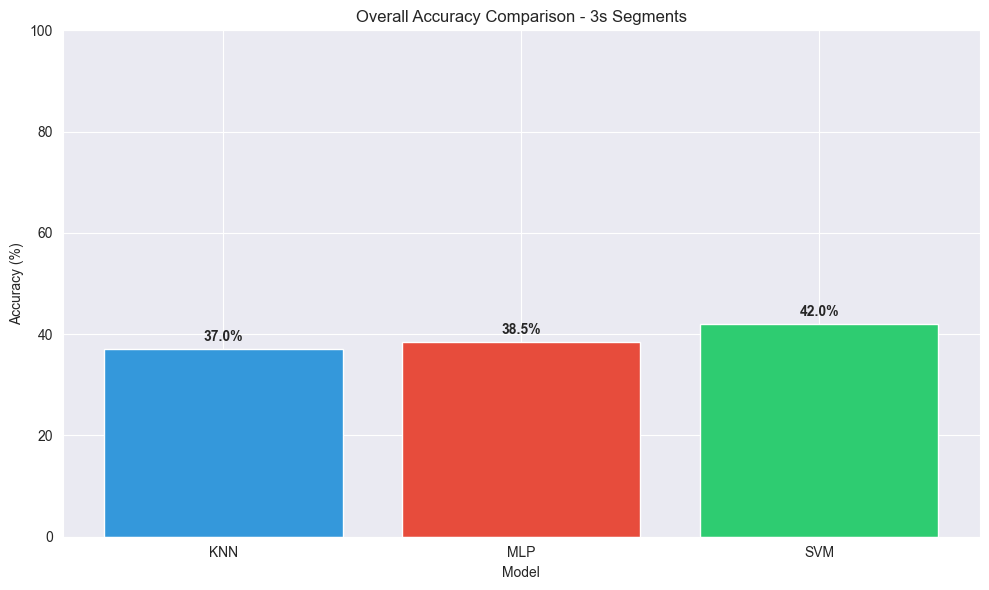


Overall Accuracies (3s):
KNN: 37.00%
MLP: 38.50%
SVM: 42.00%

CHARTS FOR 6 SECOND SEGMENTS


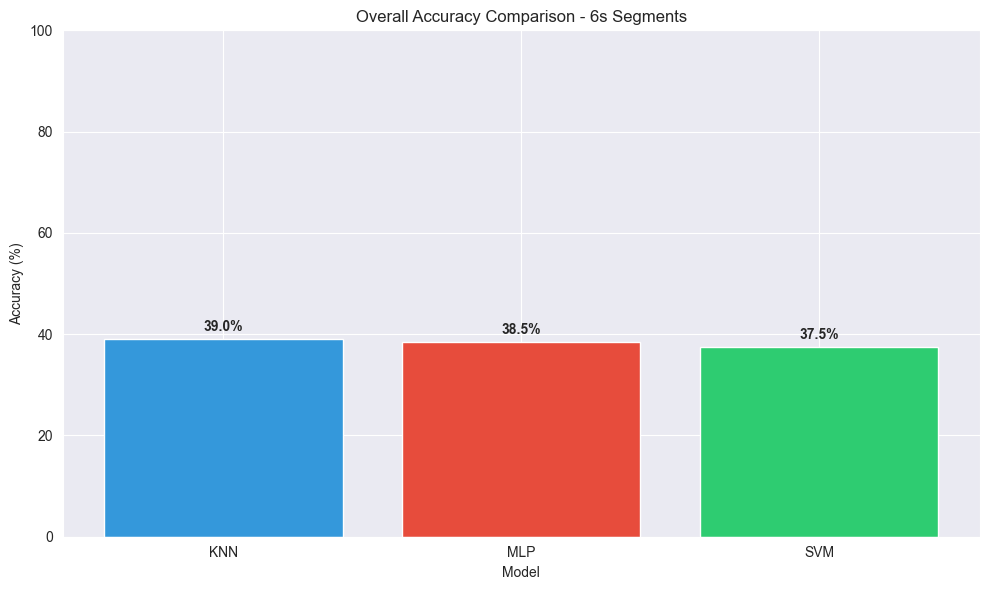


Overall Accuracies (6s):
KNN: 39.00%
MLP: 38.50%
SVM: 37.50%

CHARTS FOR 10 SECOND SEGMENTS


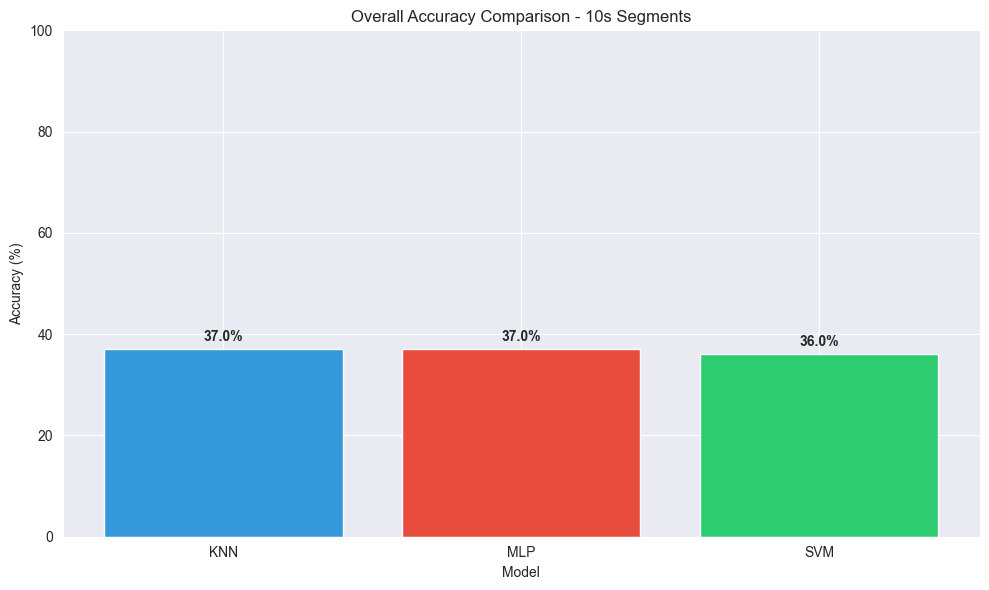


Overall Accuracies (10s):
KNN: 37.00%
MLP: 37.00%
SVM: 36.00%


In [20]:
# Generate charts for each segment duration
for segment_duration, df_results in all_predictions.items():
    print(f"\n{'='*60}")
    print(f"CHARTS FOR {segment_duration} SECOND SEGMENTS")
    print(f"{'='*60}")

    # Calculate overall accuracy for each model
    accuracies = {
        'KNN': df_results['knn_correct'].mean() * 100,
        'MLP': df_results['mlp_correct'].mean() * 100,
        'SVM': df_results['svm_correct'].mean() * 100
    }

    # Bar chart of overall accuracy
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(accuracies.keys(), accuracies.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('Model')
    ax.set_title(f'Overall Accuracy Comparison - {segment_duration}s Segments')
    ax.set_ylim(0, 100)

    for bar, acc in zip(bars, accuracies.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'../data/results/accuracy_overall_{segment_duration}sec.png', dpi=150)
    plt.show()

    print(f"\nOverall Accuracies ({segment_duration}s):")
    for model, acc in accuracies.items():
        print(f"{model}: {acc:.2f}%")

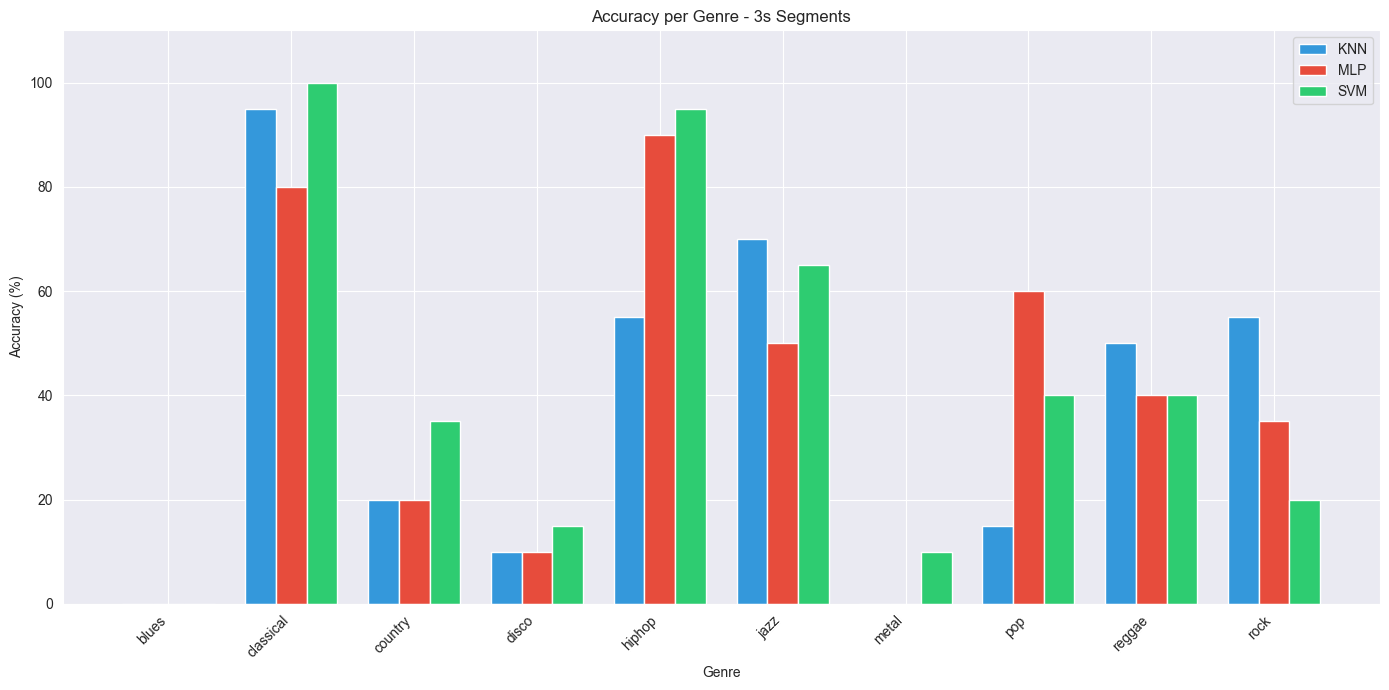


Accuracy per Genre (3s):
    Genre  KNN  MLP   SVM
    blues  0.0  0.0   0.0
classical 95.0 80.0 100.0
  country 20.0 20.0  35.0
    disco 10.0 10.0  15.0
   hiphop 55.0 90.0  95.0
     jazz 70.0 50.0  65.0
    metal  0.0  0.0  10.0
      pop 15.0 60.0  40.0
   reggae 50.0 40.0  40.0
     rock 55.0 35.0  20.0


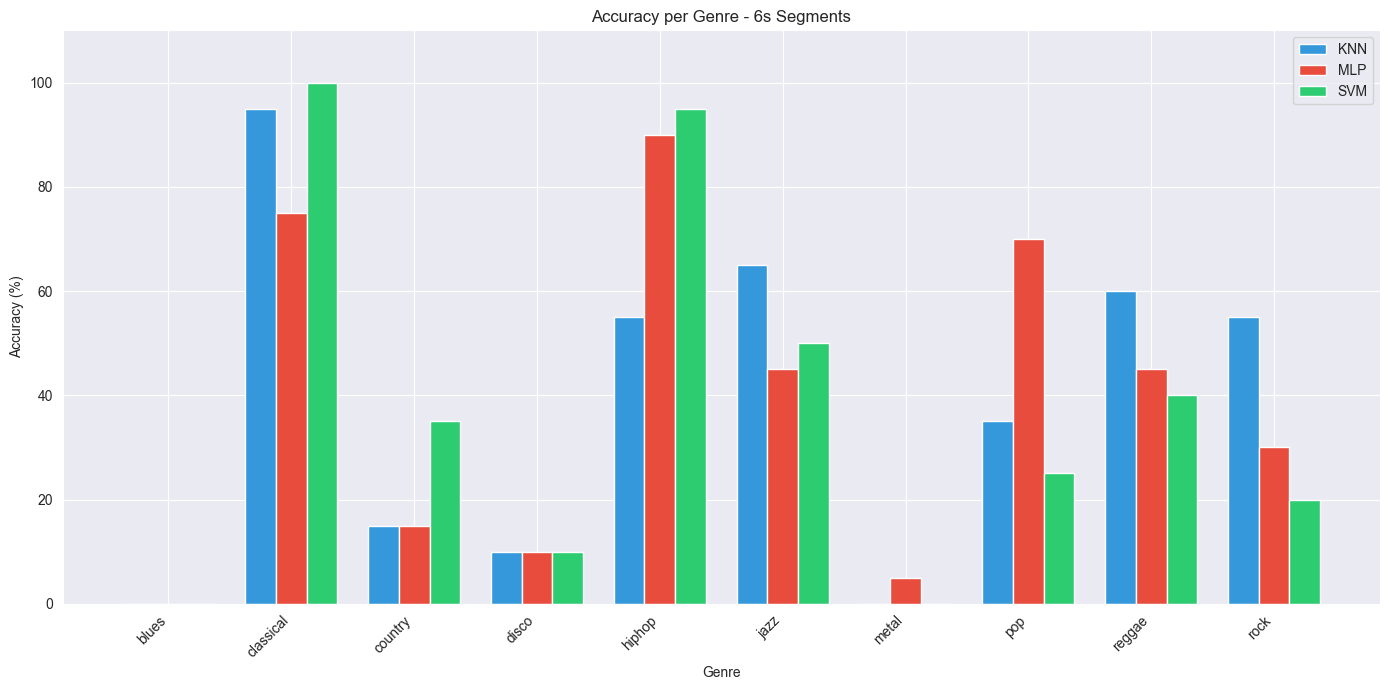


Accuracy per Genre (6s):
    Genre  KNN  MLP   SVM
    blues  0.0  0.0   0.0
classical 95.0 75.0 100.0
  country 15.0 15.0  35.0
    disco 10.0 10.0  10.0
   hiphop 55.0 90.0  95.0
     jazz 65.0 45.0  50.0
    metal  0.0  5.0   0.0
      pop 35.0 70.0  25.0
   reggae 60.0 45.0  40.0
     rock 55.0 30.0  20.0


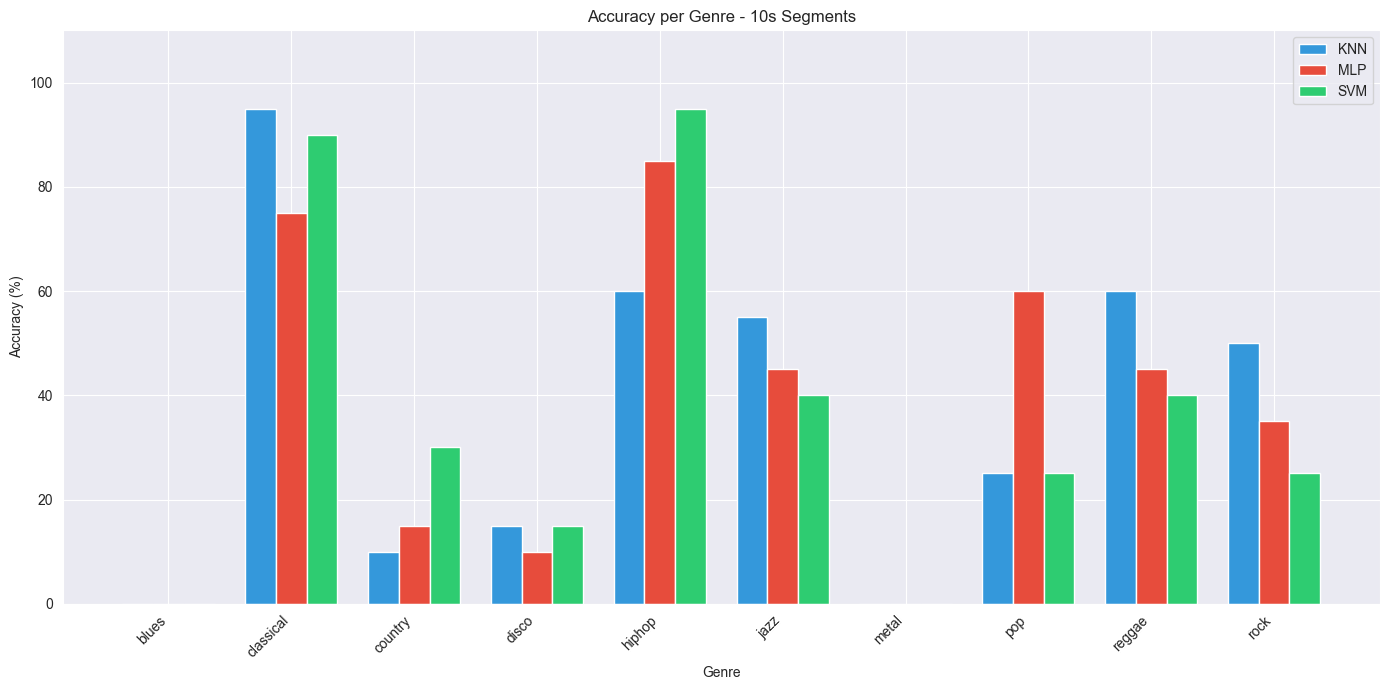


Accuracy per Genre (10s):
    Genre  KNN  MLP  SVM
    blues  0.0  0.0  0.0
classical 95.0 75.0 90.0
  country 10.0 15.0 30.0
    disco 15.0 10.0 15.0
   hiphop 60.0 85.0 95.0
     jazz 55.0 45.0 40.0
    metal  0.0  0.0  0.0
      pop 25.0 60.0 25.0
   reggae 60.0 45.0 40.0
     rock 50.0 35.0 25.0


In [21]:
# Accuracy per genre charts for each segment duration
for segment_duration, df_results in all_predictions.items():
    genre_accuracy = df_results.groupby('actual_genre').agg({
        'knn_correct': 'mean',
        'mlp_correct': 'mean',
        'svm_correct': 'mean'
    }).reset_index()

    genre_accuracy.columns = ['Genre', 'KNN', 'MLP', 'SVM']
    genre_accuracy[['KNN', 'MLP', 'SVM']] *= 100

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(genre_accuracy['Genre']))
    width = 0.25

    bars1 = ax.bar(x - width, genre_accuracy['KNN'], width, label='KNN', color='#3498db')
    bars2 = ax.bar(x, genre_accuracy['MLP'], width, label='MLP', color='#e74c3c')
    bars3 = ax.bar(x + width, genre_accuracy['SVM'], width, label='SVM', color='#2ecc71')

    ax.set_ylabel('Accuracy (%)')
    ax.set_xlabel('Genre')
    ax.set_title(f'Accuracy per Genre - {segment_duration}s Segments')
    ax.set_xticks(x)
    ax.set_xticklabels(genre_accuracy['Genre'], rotation=45, ha='right')
    ax.set_ylim(0, 110)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'../data/results/accuracy_per_genre_{segment_duration}sec.png', dpi=150)
    plt.show()

    print(f"\nAccuracy per Genre ({segment_duration}s):")
    print(genre_accuracy.to_string(index=False))

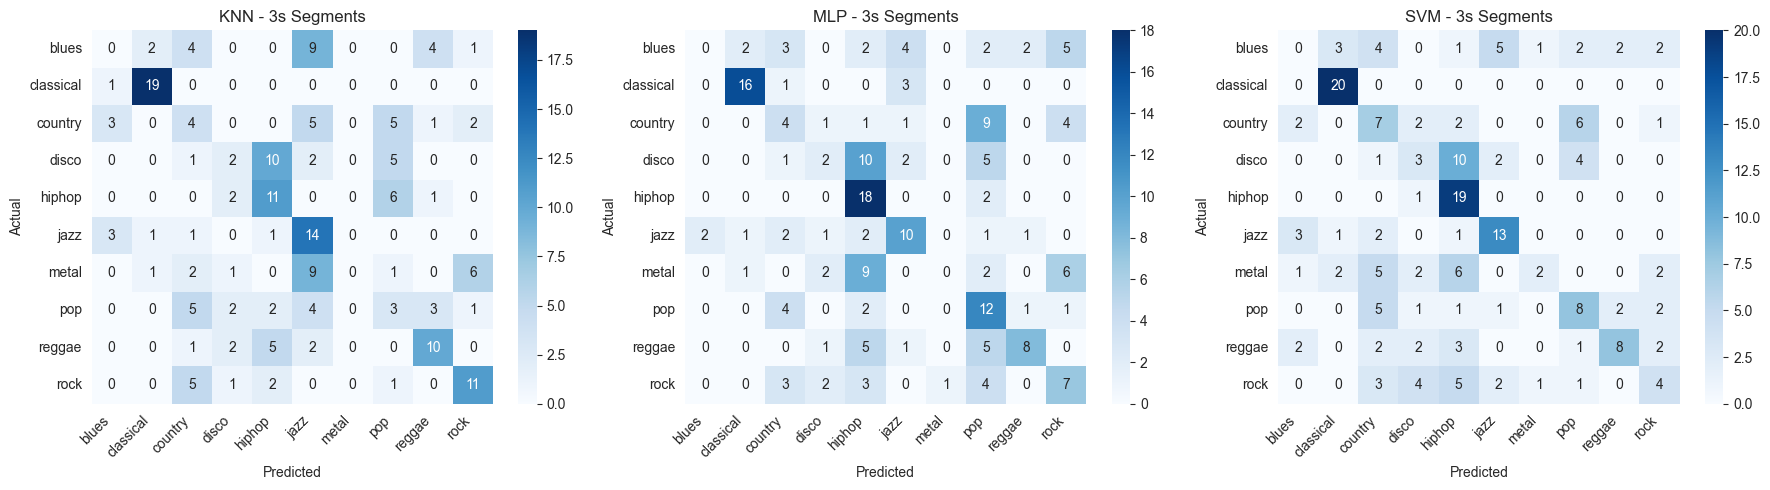

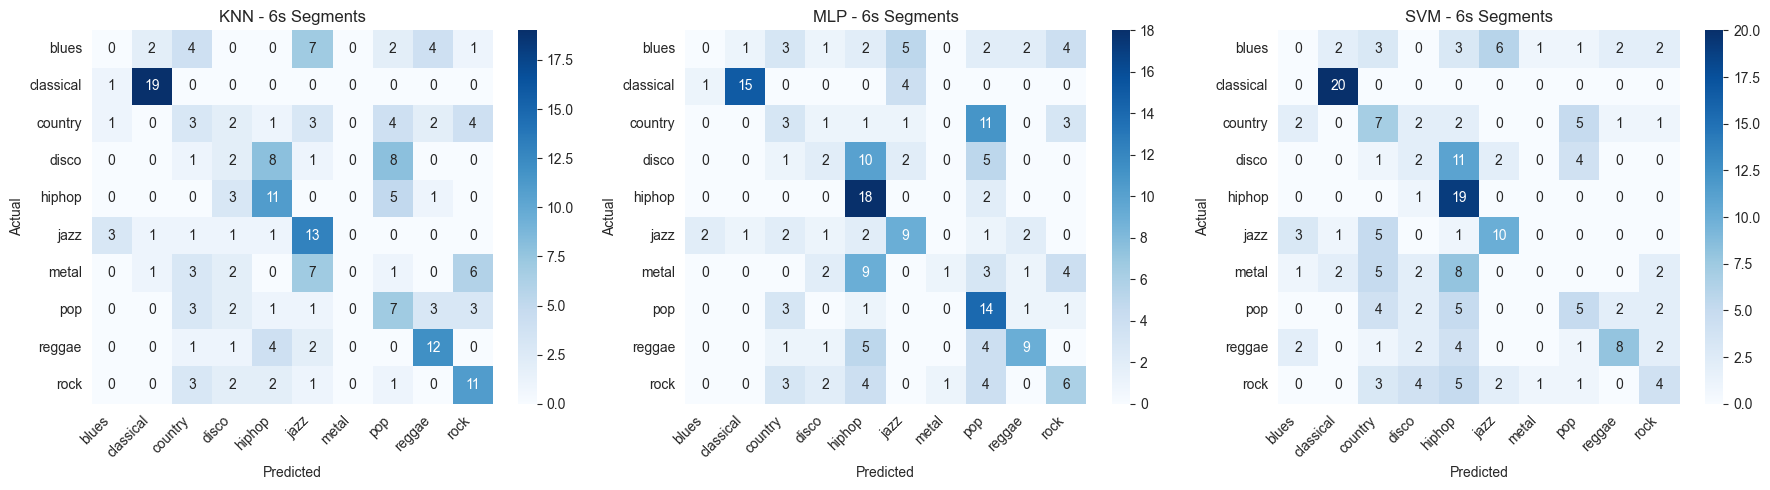

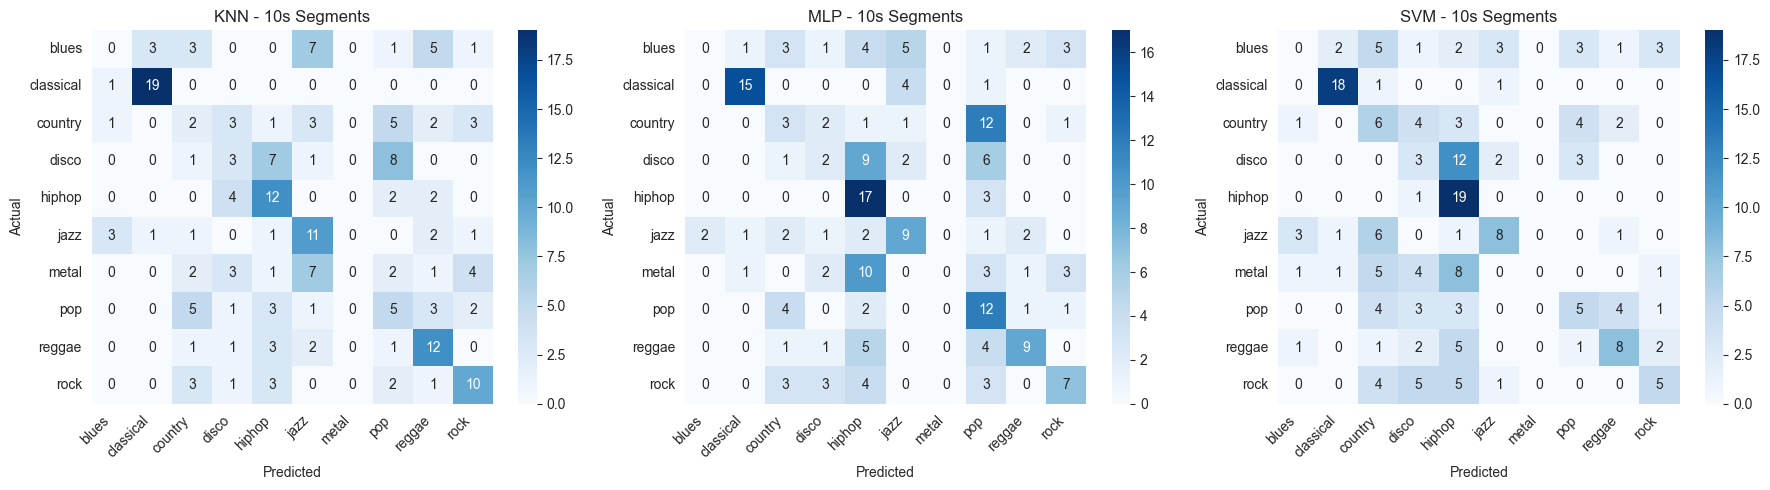

In [22]:
# Confusion matrices for each segment duration
for segment_duration, df_results in all_predictions.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    models_data = [
        ('KNN', 'knn_prediction', axes[0]),
        ('MLP', 'mlp_prediction', axes[1]),
        ('SVM', 'svm_prediction', axes[2])
    ]

    all_genres = sorted(df_results['actual_genre'].unique())

    for model_name, pred_col, ax in models_data:
        cm = confusion_matrix(df_results['actual_genre'], df_results[pred_col], labels=all_genres)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=all_genres, yticklabels=all_genres, ax=ax)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{model_name} - {segment_duration}s Segments')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'../data/results/confusion_matrices_{segment_duration}sec.png', dpi=150)
    plt.show()

### Comparison Charts Across All Segment Durations

In [23]:
# Collect accuracies for all segment durations
comparison_data = []

for segment_duration, df_results in all_predictions.items():
    comparison_data.append({
        'Segment Duration': f'{segment_duration}s',
        'KNN': df_results['knn_correct'].mean() * 100,
        'MLP': df_results['mlp_correct'].mean() * 100,
        'SVM': df_results['svm_correct'].mean() * 100
    })

df_comparison = pd.DataFrame(comparison_data)
print("Accuracy Comparison Across Segment Durations:")
print(df_comparison.to_string(index=False))

Accuracy Comparison Across Segment Durations:
Segment Duration  KNN  MLP  SVM
              3s 37.0 38.5 42.0
              6s 39.0 38.5 37.5
             10s 37.0 37.0 36.0


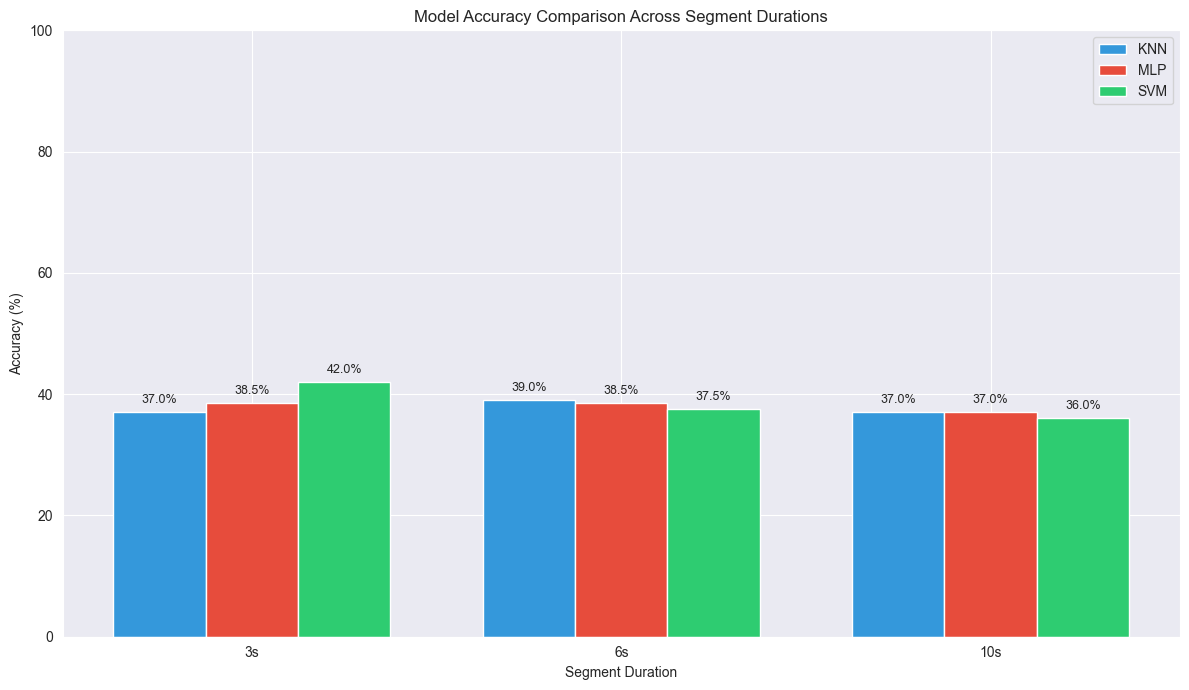

In [24]:
# Grouped bar chart comparing all segment durations
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(df_comparison['Segment Duration']))
width = 0.25

bars1 = ax.bar(x - width, df_comparison['KNN'], width, label='KNN', color='#3498db')
bars2 = ax.bar(x, df_comparison['MLP'], width, label='MLP', color='#e74c3c')
bars3 = ax.bar(x + width, df_comparison['SVM'], width, label='SVM', color='#2ecc71')

ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Segment Duration')
ax.set_title('Model Accuracy Comparison Across Segment Durations')
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Segment Duration'])
ax.set_ylim(0, 100)
ax.legend()

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../data/results/accuracy_comparison_all_segments.png', dpi=150)
plt.show()

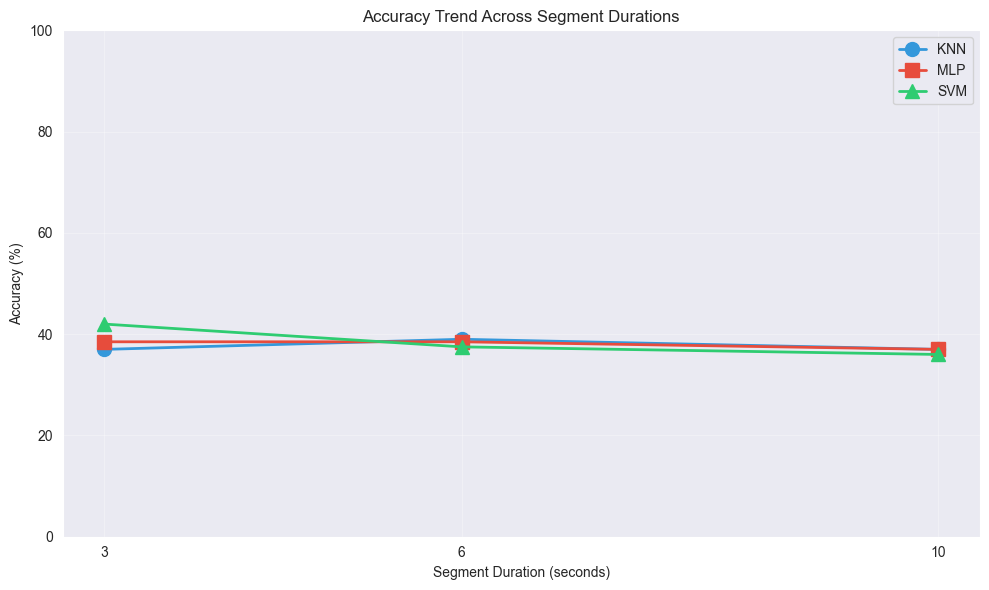

In [25]:
# Line chart showing accuracy trends across segment durations
fig, ax = plt.subplots(figsize=(10, 6))

segment_labels = [3, 6, 10]
ax.plot(segment_labels, df_comparison['KNN'], 'o-', label='KNN', color='#3498db', linewidth=2, markersize=10)
ax.plot(segment_labels, df_comparison['MLP'], 's-', label='MLP', color='#e74c3c', linewidth=2, markersize=10)
ax.plot(segment_labels, df_comparison['SVM'], '^-', label='SVM', color='#2ecc71', linewidth=2, markersize=10)

ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Segment Duration (seconds)')
ax.set_title('Accuracy Trend Across Segment Durations')
ax.set_xticks(segment_labels)
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/results/accuracy_trend_all_segments.png', dpi=150)
plt.show()

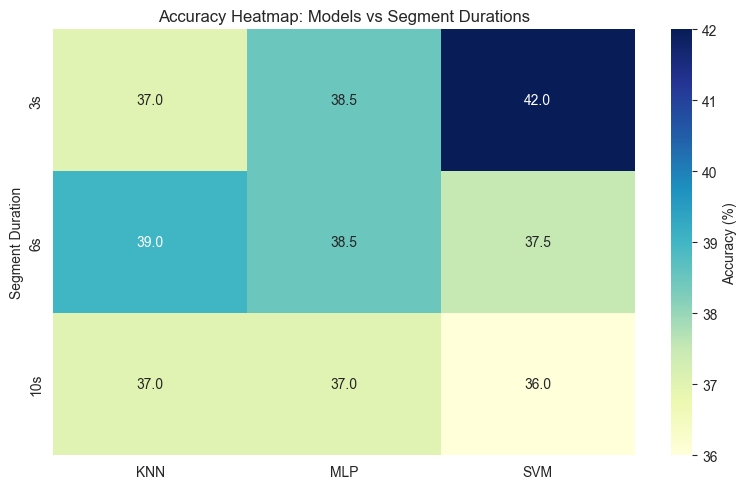

In [26]:
# Heatmap comparison
fig, ax = plt.subplots(figsize=(8, 5))

heatmap_data = df_comparison.set_index('Segment Duration')[['KNN', 'MLP', 'SVM']]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Accuracy (%)'})
ax.set_title('Accuracy Heatmap: Models vs Segment Durations')
ax.set_ylabel('Segment Duration')

plt.tight_layout()
plt.savefig('../data/results/accuracy_heatmap_all_segments.png', dpi=150)
plt.show()

### Summary Statistics

In [27]:
print("="*60)
print("OVERALL SUMMARY STATISTICS")
print("="*60)

for segment_duration, df_results in all_predictions.items():
    all_genres = sorted(df_results['actual_genre'].unique())

    accuracies = {
        'KNN': df_results['knn_correct'].mean() * 100,
        'MLP': df_results['mlp_correct'].mean() * 100,
        'SVM': df_results['svm_correct'].mean() * 100
    }

    best_model = max(accuracies, key=accuracies.get)

    print(f"\n{'-'*60}")
    print(f"{segment_duration} SECOND SEGMENTS")
    print(f"{'-'*60}")
    print(f"Total songs tested: {len(df_results)}")
    print(f"Genres tested: {len(all_genres)}")
    print(f"\nCorrect predictions:")
    print(f"  KNN: {df_results['knn_correct'].sum()}/{len(df_results)} ({accuracies['KNN']:.2f}%)")
    print(f"  MLP: {df_results['mlp_correct'].sum()}/{len(df_results)} ({accuracies['MLP']:.2f}%)")
    print(f"  SVM: {df_results['svm_correct'].sum()}/{len(df_results)} ({accuracies['SVM']:.2f}%)")
    print(f"\nBest performing model: {best_model} ({accuracies[best_model]:.2f}%)")

# Find overall best configuration
print(f"\n{'='*60}")
print("BEST CONFIGURATION")
print("="*60)

best_accuracy = 0
best_config = None

for segment_duration, df_results in all_predictions.items():
    for model, col in [('KNN', 'knn_correct'), ('MLP', 'mlp_correct'), ('SVM', 'svm_correct')]:
        acc = df_results[col].mean() * 100
        if acc > best_accuracy:
            best_accuracy = acc
            best_config = (model, segment_duration)

print(f"Best overall: {best_config[0]} with {best_config[1]}s segments ({best_accuracy:.2f}%)")

OVERALL SUMMARY STATISTICS

------------------------------------------------------------
3 SECOND SEGMENTS
------------------------------------------------------------
Total songs tested: 200
Genres tested: 10

Correct predictions:
  KNN: 74/200 (37.00%)
  MLP: 77/200 (38.50%)
  SVM: 84/200 (42.00%)

Best performing model: SVM (42.00%)

------------------------------------------------------------
6 SECOND SEGMENTS
------------------------------------------------------------
Total songs tested: 200
Genres tested: 10

Correct predictions:
  KNN: 78/200 (39.00%)
  MLP: 77/200 (38.50%)
  SVM: 75/200 (37.50%)

Best performing model: KNN (39.00%)

------------------------------------------------------------
10 SECOND SEGMENTS
------------------------------------------------------------
Total songs tested: 200
Genres tested: 10

Correct predictions:
  KNN: 74/200 (37.00%)
  MLP: 74/200 (37.00%)
  SVM: 72/200 (36.00%)

Best performing model: KNN (37.00%)

BEST CONFIGURATION
Best overall: SVM w

In [28]:
# Detailed classification reports for each configuration
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

for segment_duration, df_results in all_predictions.items():
    print(f"\n{'='*60}")
    print(f"{segment_duration} SECOND SEGMENTS - Classification Reports")
    print("="*60)

    for model_name, pred_col in [('KNN', 'knn_prediction'), ('MLP', 'mlp_prediction'), ('SVM', 'svm_prediction')]:
        print(f"\n{model_name} Classification Report ({segment_duration}s):")
        print(classification_report(df_results['actual_genre'], df_results[pred_col]))


DETAILED CLASSIFICATION REPORTS

3 SECOND SEGMENTS - Classification Reports

KNN Classification Report (3s):
              precision    recall  f1-score   support

       blues       0.00      0.00      0.00        20
   classical       0.83      0.95      0.88        20
     country       0.17      0.20      0.19        20
       disco       0.20      0.10      0.13        20
      hiphop       0.35      0.55      0.43        20
        jazz       0.31      0.70      0.43        20
       metal       0.00      0.00      0.00        20
         pop       0.14      0.15      0.15        20
      reggae       0.53      0.50      0.51        20
        rock       0.52      0.55      0.54        20

    accuracy                           0.37       200
   macro avg       0.31      0.37      0.33       200
weighted avg       0.31      0.37      0.33       200


MLP Classification Report (3s):
              precision    recall  f1-score   support

       blues       0.00      0.00      0.00

In [30]:
# Save comparison summary to CSV
df_comparison.to_csv('../data/results/segment_duration_comparison.csv', index=False)
print("Comparison summary saved to ../data/results/segment_duration_comparison.csv")

print("\nAll charts saved to ../data/results/")


Comparison summary saved to ../data/results/segment_duration_comparison.csv

All charts saved to ../data/results/
